# 04 · Calibration and cost-based decisioning — the centerpiece

**The question this notebook answers:** once the model gives every applicant a
probability of default, *how should the lender turn that number into
approve / reject?*

Two jobs happen here, in order:

1. **Calibration** — make the probability *mean what it says*. If the model
   says 10% for a group of applicants, about 10% of them should default.
2. **Decisioning** — compare that probability with a per-applicant threshold
   `t*(x)` derived from the money at stake on *that* loan.

Everything below is computed on **development data** (the 80% we are
allowed to look at). The final quoted numbers came from the one-shot holdout
(see the README) and are not touched here.

## 0 · Setup

**What:** imports and the project paths. **Where:** every path comes from
`config/constants.py` — no file paths are typed in notebooks.

In [1]:
import os, sys, json
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
from IPython.display import Image
from config.constants import TABLES_DIR, FIGURES_DIR, DATA_PROCESSED, ARTIFACTS_DIR
pd.set_option("display.width", 140)

## 1 · Load the out-of-fold predictions

**What:** one row per development applicant with three numbers:
`p_raw` (the model's raw score), `p_cal_crossfit` (the calibrated
probability) and `TARGET` (1 = had payment difficulties).

**Why "out-of-fold" (OOF):** the 246,008 development rows were split into 5
folds. Each fold was scored by a model trained on the *other four* folds, so
every prediction here was made on data the model had never seen. That is the
only honest way to grade a model on development data.

**Why "cross-fitted" calibration:** the calibrator (isotonic regression,
explained in section 2) is itself fitted to data. If we fitted it on all rows
and graded it on the same rows, it would be marking its own homework. So for
these *measurements* it was fitted on 4 folds and applied to the 5th, rotating.
The calibrator that actually ships is fitted on all OOF rows.

**Who uses it:** every number in this notebook.

In [2]:
oof = pd.read_parquet(os.path.join(DATA_PROCESSED, "oof_constrained_calibrated.parquet"))
print(f"{len(oof):,} development applicants, default rate {oof.TARGET.mean():.2%}")
oof.head()

246,008 development applicants, default rate 8.07%


,SK_ID_CURR,fold,TARGET,p_raw,p_cal_crossfit
0,100002,0,1,0.294788,0.271746
1,100003,2,0,0.018343,0.017153
2,100004,3,0,0.025444,0.025283
3,100006,3,0,0.060039,0.064605
4,100007,3,0,0.044008,0.049369


## 2 · Is the probability honest? Brier score and ECE

**What:** two calibration measures, computed live with
`src.models.calibration`.

- **Brier score** = the average of (probability − outcome)². Lower is better.
  A "know-nothing" forecaster that says 8.07% (the base rate) to everyone
  scores **0.0736** — that is the bar to beat ("climatology").
- **ECE (expected calibration error)** = sort applicants into 10 equal-size
  groups by predicted probability, then measure the average gap between
  *predicted* and *observed* default rate in each group.

**Why it matters here more than in most projects:** the decision rule
multiplies the probability by money. A probability that says 20% when the
truth is 12% would make every threshold wrong.

**How isotonic regression works (from scratch):** it learns a step function
that maps raw score → probability, with one rule: it can never go down (a
higher raw score never gets a lower probability). It only *re-labels* scores;
it never re-orders applicants, so it cannot change AUC (a ranking metric).

In [3]:
from src.models.calibration import brier, ece_and_reliability

y = oof.TARGET.values
b_raw, b_cal = brier(y, oof.p_raw.values), brier(y, oof.p_cal_crossfit.values)
e_raw, _ = ece_and_reliability(y, oof.p_raw.values)
e_cal, rel = ece_and_reliability(y, oof.p_cal_crossfit.values)
print(f"Brier  raw {b_raw:.5f} → calibrated {b_cal:.5f}   (climatology 0.0736)")
print(f"ECE    raw {e_raw:.5f} → calibrated {e_cal:.5f}")
rel.round(4)

Brier  raw 0.06678 → calibrated 0.06671   (climatology 0.0736)
ECE    raw 0.00469 → calibrated 0.00078


,bin,mean_pred,obs_rate,n
0,0,0.0093,0.0097,24601
1,1,0.0161,0.0163,24601
2,2,0.0242,0.0247,24601
3,3,0.0315,0.0316,24600
4,4,0.0428,0.0436,24601
5,5,0.0575,0.0559,24601
6,6,0.0787,0.0800,24600
7,7,0.1044,0.1040,24601
8,8,0.1535,0.1541,24601
9,9,0.2893,0.2874,24601


**How to read it:** in the table, `mean_pred` and `obs_rate` should be close
in every row — that is what "calibrated" means. The reliability diagram below
is the same table as a picture: points on the diagonal = honest probabilities.

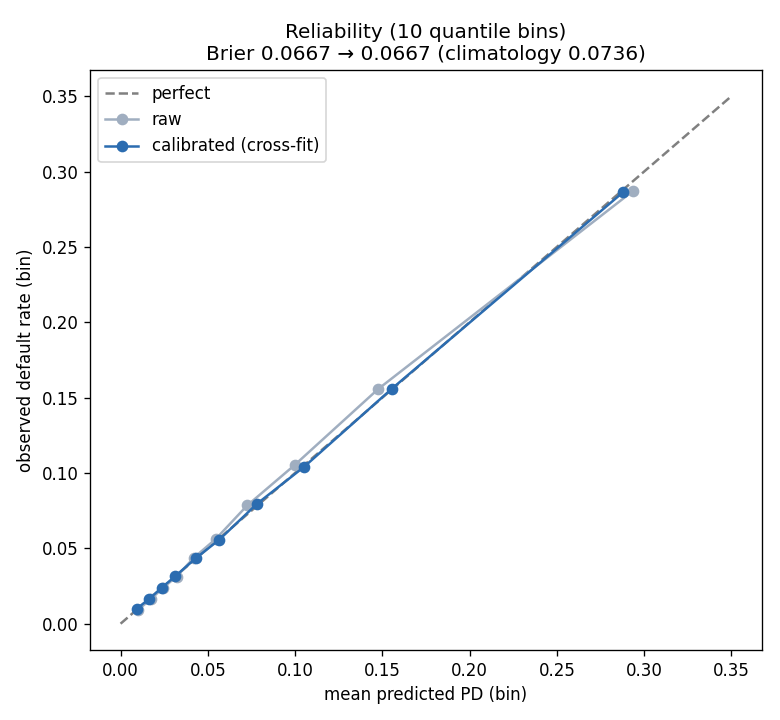

In [4]:
Image(os.path.join(FIGURES_DIR, "41_reliability.png"))

## 3 · Does the calibrator fit the model that actually ships?

**What:** the deployed scorer is the **average of the 5 fold models**, not any
single one. The calibrator was fitted on OOF scores (each from *one* model).
Averaging five models can squeeze or stretch the score distribution, so we
*measure* how different the two distributions are rather than assuming they
match.

**How to read it:** PSI (population stability index) near 0 means the two
distributions are practically the same; below 0.10 is "stable" by industry
convention. The overlay figure shows the two histograms on top of each other.

PSI 0.00019   KS 0.0038   std ratio 1.019
measured: ensemble std 1.9% LARGER than OOF (in-sample sharpness of 4/5 models on dev rows outweighs averaging compression, as in Phase 4); PSI 0.00019 — second-order, calibrator alignment verified


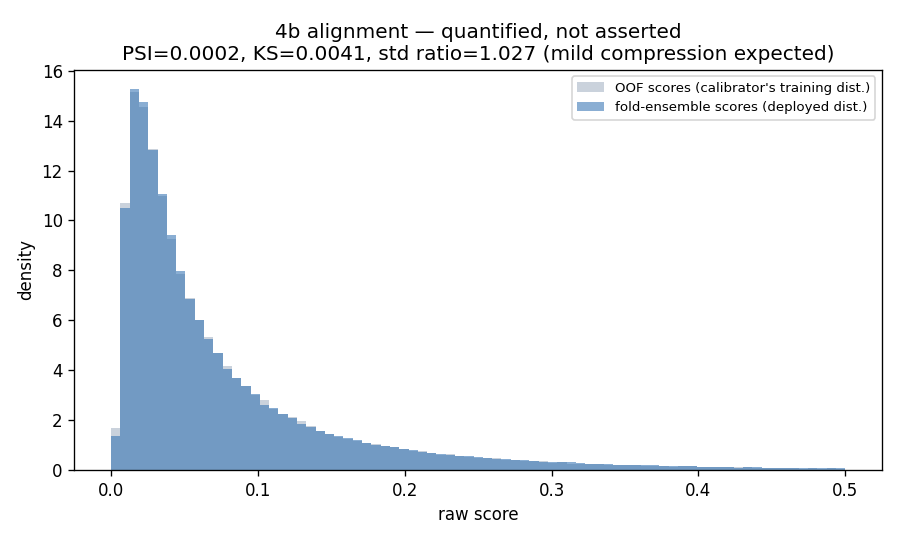

In [5]:
al = json.load(open(os.path.join(TABLES_DIR, "final_pipeline.json")))["alignment"]
print(f"PSI {al['psi']:.5f}   KS {al['ks_statistic']:.4f}   std ratio {al['compression_ratio_std']:.3f}")
print(al["note"])
Image(os.path.join(FIGURES_DIR, "42_alignment_overlay.png"))

## 4 · The decision rule, worked by hand for one loan

**What:** the threshold formula, derived from expected profit.

For one applicant with probability of default `p` and loan amount `A`:

| | repays (1 − p) | defaults (p) |
|---|---|---|
| **approve** | earn `m(x)·A` (net margin) | lose `LGD·EAD·A` |
| **reject** | 0 | 0 |

Approve when the expected value is positive:
`(1 − p)·m·A − p·LGD·EAD·A > 0`. Divide by `A` and rearrange:

**approve iff  p < t\*(x) = m / (m + LGD·EAD)**

- `m(x)` — net margin as a share of the loan. For a cash loan:
  `5% a year × term ÷ 2`. The **÷ 2** is the amortization correction: the
  borrower repays principal every month, so on average only half the loan is
  outstanding.
- `LGD` — share of the exposure lost if the borrower defaults (0.70 cash).
- `EAD` — share of the original amount still exposed at default (0.85 cash).

**These constants are illustrative assumptions, not estimates** — the dataset
has no recovery, exposure or pricing data. They were frozen before any result
existed so they could not be tuned to flatter the outcome.

**Where:** `src.models.decision.attach_cost_params` is the single implementation.
Below, the spec's sanity anchor — a 3-year cash loan — by hand and by the code.

In [6]:
from src.features.stateless import implied_term_years
from src.models.decision import attach_cost_params

m = 0.05 * 3 / 2
L = 0.70 * 0.85
print(f"by hand: m = {m:.3f}, LGD·EAD = {L:.3f}, t* = {m / (m + L):.4f}")

A = 100_000.0
loan = pd.DataFrame({"NAME_CONTRACT_TYPE": ["Cash loans"], "AMT_CREDIT": [A],
                     "term_years": implied_term_years(pd.Series([A]), pd.Series([A / 36]))})
print(f"by code: t* = {attach_cost_params(loan).t_star.iloc[0]:.4f}")

by hand: m = 0.075, LGD·EAD = 0.595, t* = 0.1119
by code: t* = 0.1119


**Why one threshold per applicant:** short loans earn little margin, so they
get *strict* thresholds; long loans earn more, so they get more lenient ones;
revolving credit has its own economics. The histogram shows the spread of
`t*(x)` across the book (roughly 0.03 to 0.17).

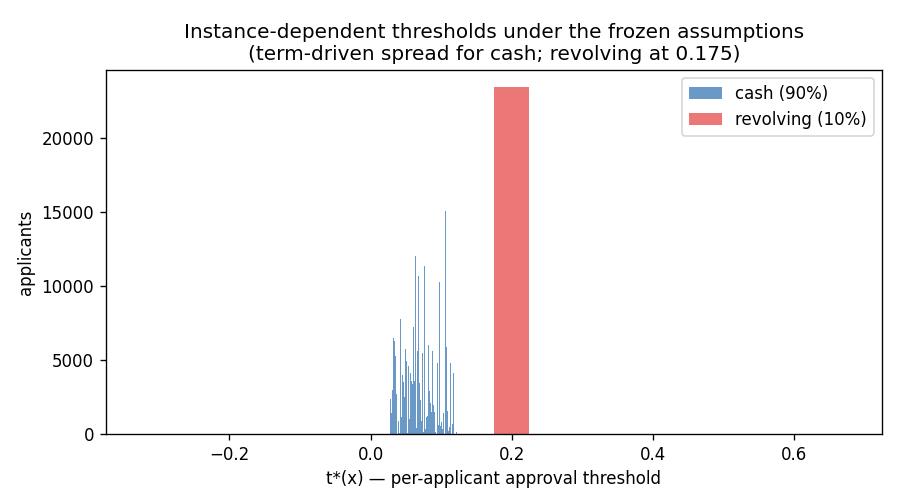

In [7]:
Image(os.path.join(FIGURES_DIR, "43_t_star_hist.png"))

## 5 · Is the per-applicant rule better than one global threshold?

**What:** the honest comparison. The naive 0.5 threshold is a straw man (it
approves almost everyone). The real competitor is the **best possible single
threshold**, found by trying 99 cut-offs from 0.01 to 0.50.

**How profit is counted (the frozen "ledger"):** approved and repaid → +margin;
approved and defaulted → −loss; rejected → 0. Realized outcomes, never
probabilities.

**Why cross-fitted here:** picking the best flat threshold on the same rows
you score it on flatters the flat policy (it gets to see the answers). Below,
each fold's flat threshold is chosen on the *other four* folds —
`src.models.decision.crossfit_flat_approvals`.

In [8]:
from src.data.load import load_modeling_frame
from src.models.decision import crossfit_flat_approvals, realized_profit

cols = load_modeling_frame("dev")[["SK_ID_CURR", "NAME_CONTRACT_TYPE", "term_years", "AMT_CREDIT"]]
d = attach_cost_params(oof.merge(cols, on="SK_ID_CURR", validate="one_to_one"))
p, y, folds = d.p_cal_crossfit.values, d.TARGET.values, d.fold.values
per10k = 1e4 / len(d)

profit = {
    "naive 0.5": realized_profit(p < 0.5, y, d),
    "best single flat (cross-fitted)": realized_profit(crossfit_flat_approvals(p, y, d, folds), y, d),
    "per-applicant t*(x)": realized_profit(p < d.t_star.values, y, d),
}
for k, v in profit.items():
    print(f"{k:>32}: {v * per10k:>14,.0f} currency units per 10k applications")
flat = profit["best single flat (cross-fitted)"]
print(f"\ngain over best flat: {(profit['per-applicant t*(x)'] - flat) / abs(flat):+.2%}")

                       naive 0.5:     67,910,502 currency units per 10k applications
 best single flat (cross-fitted):    162,192,094 currency units per 10k applications
             per-applicant t*(x):    171,341,615 currency units per 10k applications

gain over best flat: +5.64%


**Currency:** the dataset never states one (median income 147,150; median
loan 513,531 — not plausibly euros), so amounts are in the dataset's own units.
The percentage is the currency-free claim.

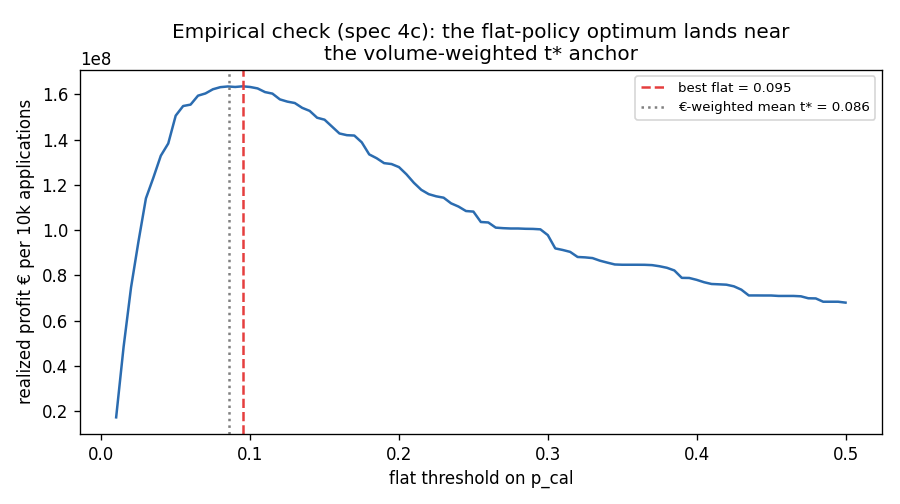

In [9]:
Image(os.path.join(FIGURES_DIR, "44_flat_sweep.png"))

## 6 · Who changes sides? The swap-set

**What:** compare the per-applicant rule with the naive 0.5 rule and count the
applicants each one approves that the other rejects, with their *observed*
default rates.

**How to read it:** the "swapped OUT" row is the people the cost rule turns
away that 0.5 would have approved. If they default far above the 8% base
rate, the rule is rejecting the right people.

In [10]:
pd.read_csv(os.path.join(TABLES_DIR, "swap_set_oof.csv"))

,cell,n,default_rate,net_eur_under_new,net_eur_under_base
0,approved by both,153136,0.034734,4.222334e+09,4.222334e+09
1,"swapped IN (new approves, base rejects)",0,NaN,0.000000e+00,0.000000e+00
2,"swapped OUT (new rejects, base approves)",91660,0.151364,0.000000e+00,-2.551618e+09
3,rejected by both,1212,0.550330,0.000000e+00,0.000000e+00


## 7 · How much of the gain is just segmentation?

**What (added after the October 2026 review, development data only):** a
fairer, stronger competitor. Instead of *one* flat threshold, fit a separate
flat threshold for each **segment** — revolving loans, and cash loans split
into 5 term buckets (6 thresholds), cross-fitted the same way. This
competitor knows contract type and term but nothing about the loan economics.

**Why it matters:** if a fitted 6-threshold policy did as well, the cost
formula would be decorative. It captures most of the gain — so most of the
value is *term and contract segmentation* — but the closed-form `t*(x)`
still wins, and it needs no fitting at all.

**Where:** `scripts/run_sensitivity_dev.py` (≈ 90 s) writes the table; this
cell loads it.

In [11]:
sens = json.load(open(os.path.join(TABLES_DIR, "sensitivity_dev_full.json")))
print(sens["label"], "\n")
for k, v in sens["segmentation_benchmark"].items():
    print(f"{k:>58}: {v['gain_vs_single_flat']:+.2%}")
print(f"\nshare of the t*(x) gain captured by the 6-segment policy: "
      f"{sens['share_of_gain_captured_by_6_segment_policy']:.0%}")

DEVELOPMENT evidence (dev OOF, cross-fitted comparators) — added after the holdout ceremony; does not revise any pre-registered holdout number 

                                single flat (cross-fitted): +0.00%
       flat per contract type (2 thresholds, cross-fitted): +2.17%
  flat per contract × cash-term quintile (6, cross-fitted): +5.15%
                     instance-dependent t*(x) (no fitting): +5.64%

share of the t*(x) gain captured by the 6-segment policy: 91%


## 8 · Do the conclusions survive different assumptions?

**What:** re-run the comparison under every value in the frozen sensitivity
grids — all six cost parameters — plus the **cure rate**.

**Cure rate, from scratch:** `TARGET = 1` means *early* payment difficulty,
not a written-off loan. Many early-delinquent borrowers catch up ("cure").
LGD and EAD describe *written-off* loans. If a share `c` of TARGET=1 cases
cure with no loss, the expected loss shrinks to `(1 − c)·LGD·EAD` and every
threshold loosens: `t* = m / (m + (1 − c)·LGD·EAD)`. The deployed system uses
`c = 0`; the cell below shows what a 30% or 50% cure rate does.

In [12]:
for c in (0.0, 0.30, 0.50):
    t = attach_cost_params(loan, overrides={"cure_rate": c}).t_star.iloc[0]
    print(f"cure rate {c:.0%}: 3-year cash t* = {t:.4f}")
table = pd.read_csv(os.path.join(TABLES_DIR, "sensitivity_dev_full.csv"))
table[~table.duplicate_of_frozen][["grid", "value", "gap_vs_flat_relative",
                                   "approval_rate_instance"]].round(4)

cure rate 0%: 3-year cash t* = 0.1119
cure rate 30%: 3-year cash t* = 0.1526
cure rate 50%: 3-year cash t* = 0.2013


,grid,value,gap_vs_flat_relative,approval_rate_instance
0,frozen (deployed),NaN,0.0564,0.6238
1,LGD_cash,0.60,0.0342,0.6639
3,LGD_cash,0.80,0.0565,0.5884
4,LGD_revolving,0.75,0.0616,0.6250
6,LGD_revolving,0.95,0.0528,0.6216
7,ead_cash,0.75,0.0374,0.6566
9,ead_cash,0.95,0.0583,0.5945
10,ead_revolving,0.85,0.0630,0.6251
12,r_net_cash,0.03,0.1094,0.4830
14,r_net_cash,0.08,0.0211,0.7410


**How to read it:** the gain over the best flat threshold is positive at all
14 distinct grid points (1.6% to 10.9%). The **cure rate shrinks it the most**
— at 50% cure the gain falls to 1.6% — because when losses are smaller, being
choosy matters less. The event-definition question (what TARGET really
measures) is therefore the biggest open assumption in the cost model.

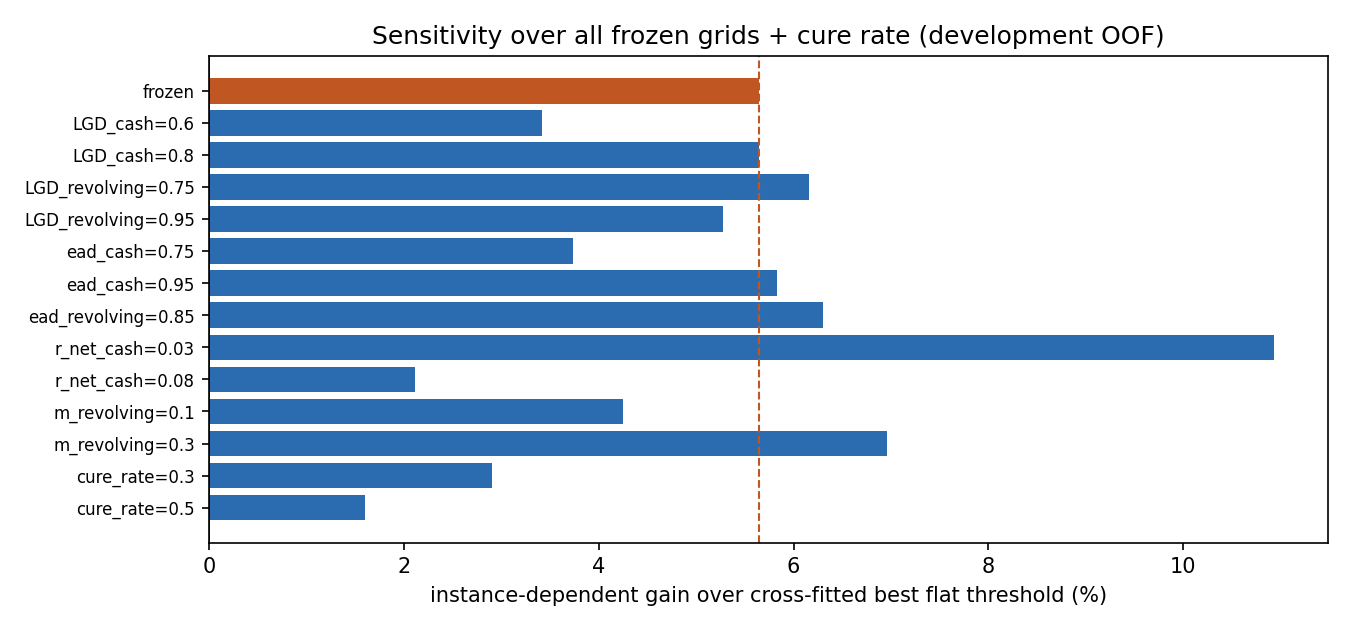

In [13]:
Image(os.path.join(FIGURES_DIR, "46_sensitivity_dev.png"))

## 9 · The view a credit committee uses: profit vs approval rate

**What:** scale every applicant's threshold up and down together and plot
expected profit against the approval rate it produces. Lenders operate to a
risk appetite ("we approve 60%"), so this curve answers "what does each extra
point of approval cost or earn?".

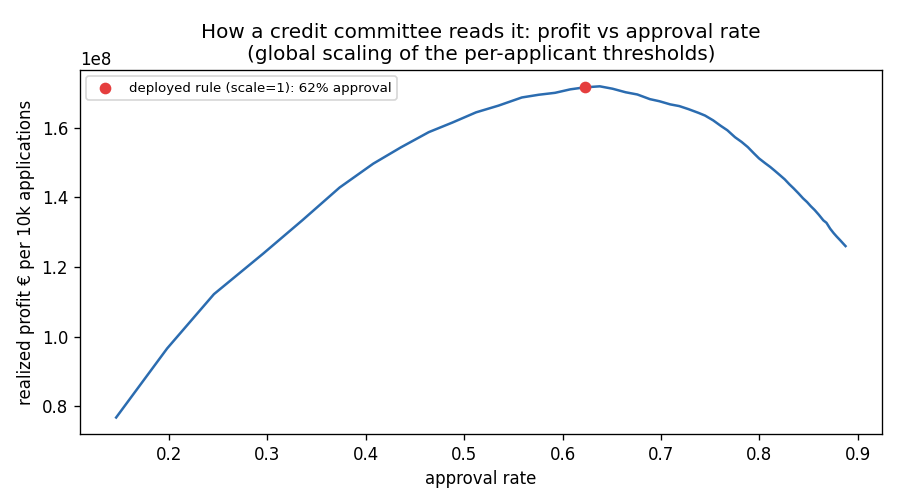

In [14]:
Image(os.path.join(FIGURES_DIR, "45_profit_vs_approval.png"))